
Tolerance = 0.001
Jacobi iterations: 10
Gauss-Seidel iterations: 7

Tolerance = 1e-06
Jacobi iterations: 17
Gauss-Seidel iterations: 10

Tolerance = 1e-09
Jacobi iterations: 25
Gauss-Seidel iterations: 14


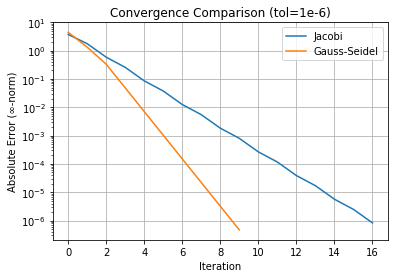

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [4, -1,  0],
    [-1, 4, -1],
    [0, -1,  3]
], dtype=float)

b = np.array([15, 10, 10], dtype=float)

x0 = np.zeros(3)

##from the slides
def jacobi(A, b, x0, tol, max_iter=10000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)

        if error < tol:
            return x_new, k+1, errors

        x = x_new

    return x, max_iter, errors

##also from slides
def gauss(A, b, x0, tol, max_iter=10000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i+1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]

        error = np.linalg.norm(x - x_old, ord=np.inf)
        errors.append(error)

        if error < tol:
            return x, k+1, errors

    return x, max_iter, errors

## now for all the parts in this

tolerances = [1e-3, 1e-6, 1e-9]

results = {}

for tol in tolerances:
    x_j, it_j, err_j = jacobi(A, b, x0, tol)
    x_gs, it_gs, err_gs = gauss(A, b, x0, tol)

    results[tol] = {
        "Jacobi_iter": it_j,
        "GS_iter": it_gs,
        "Jacobi_err": err_j,
        "GS_err": err_gs
    }

    print(f"\nTolerance = {tol}")
    print(f"Jacobi iterations: {it_j}")
    print(f"Gauss-Seidel iterations: {it_gs}")

    
## i hate this part so so so much

plt.figure()
plt.semilogy(results[1e-6]["Jacobi_err"], label="Jacobi")
plt.semilogy(results[1e-6]["GS_err"], label="Gauss-Seidel")
plt.xlabel("Iteration")
plt.ylabel("Absolute Error (∞-norm)")
plt.title("Convergence Comparison (tol=1e-6)")
plt.legend()
plt.grid()
plt.show()

## higher tolerance means less iterations
## meaning tolerance and iterations correlate inversely
## in fact nearly linear
## Jacobi is more sensetive to higher tolerances
## Gauss can accelerate convergence and go faster as seen on the graph